# ML Project: Telco Customer Churn Predictor

## 1. 🚀 Project Setup

### 1.1 Introduction

The goal of this project is to build and evaluate several machine learning models to predict customer churn (whether a customer will leave the company) based on the Telco Customer Churn dataset. We will perform data loading, exploratory data analysis, preprocessing, model training, and a comparative evaluation to identify the most effective model.

### 1.2 Loading Required Libraries

This block imports all the necessary libraries for data manipulation, visualization, modeling, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

--- 

## 2. 📊 Data Loading and Exploration

### 2.1 Extracting Data

We begin by loading the dataset from the CSV file into a pandas DataFrame and displaying the first 5 rows to understand its structure.

In [2]:
df = pd.read_csv(r"datasets/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.2 Initial Data Inspection

We use `df.info()` to get a quick overview of the data types (Dtypes), non-null counts, and memory usage. This step is crucial for identifying missing values and columns that need type conversion.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


> **Observation:**
> * We have 7043 entries and 21 columns.
> * There are no immediate `null` values according to the non-null count.
> * The `TotalCharges` column is incorrectly typed as `object` and will need to be converted to a numeric type.
> * `SeniorCitizen` is an `int64` but represents a category (0 or 1).
> * Many other columns are `object` type and will require encoding.

### 2.3 Exploratory Data Analysis (EDA)

Before preprocessing, we explore the data visually to understand the relationships between features and the target variable, `Churn`.

#### Target Variable Distribution

First, let's see the distribution of our target variable, `Churn`. This will tell us if we are dealing with an imbalanced dataset.

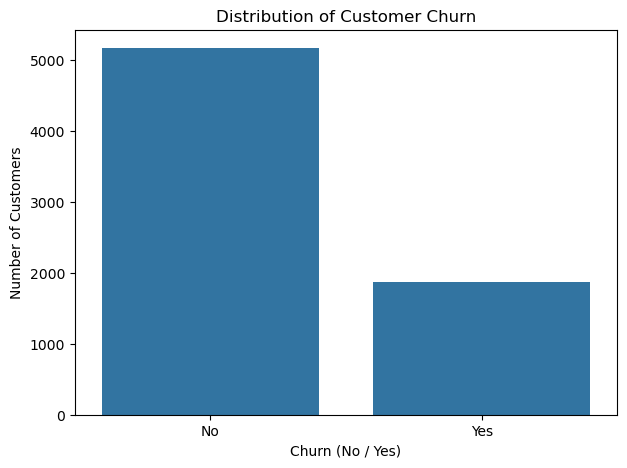

In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (No / Yes)')
plt.ylabel('Number of Customers')
plt.show()

> **Observation:** The dataset is **imbalanced**. There are significantly more non-churners (No) than churners (Yes). This is important to keep in mind, as accuracy alone might be a misleading metric. We should also focus on metrics like **Precision**, **Recall**, and **F1-Score**, especially for the 'Yes' class.

#### Churn by Key Categorical Features

Let's examine how churn varies across different categorical features like contract type, internet service, and payment method.

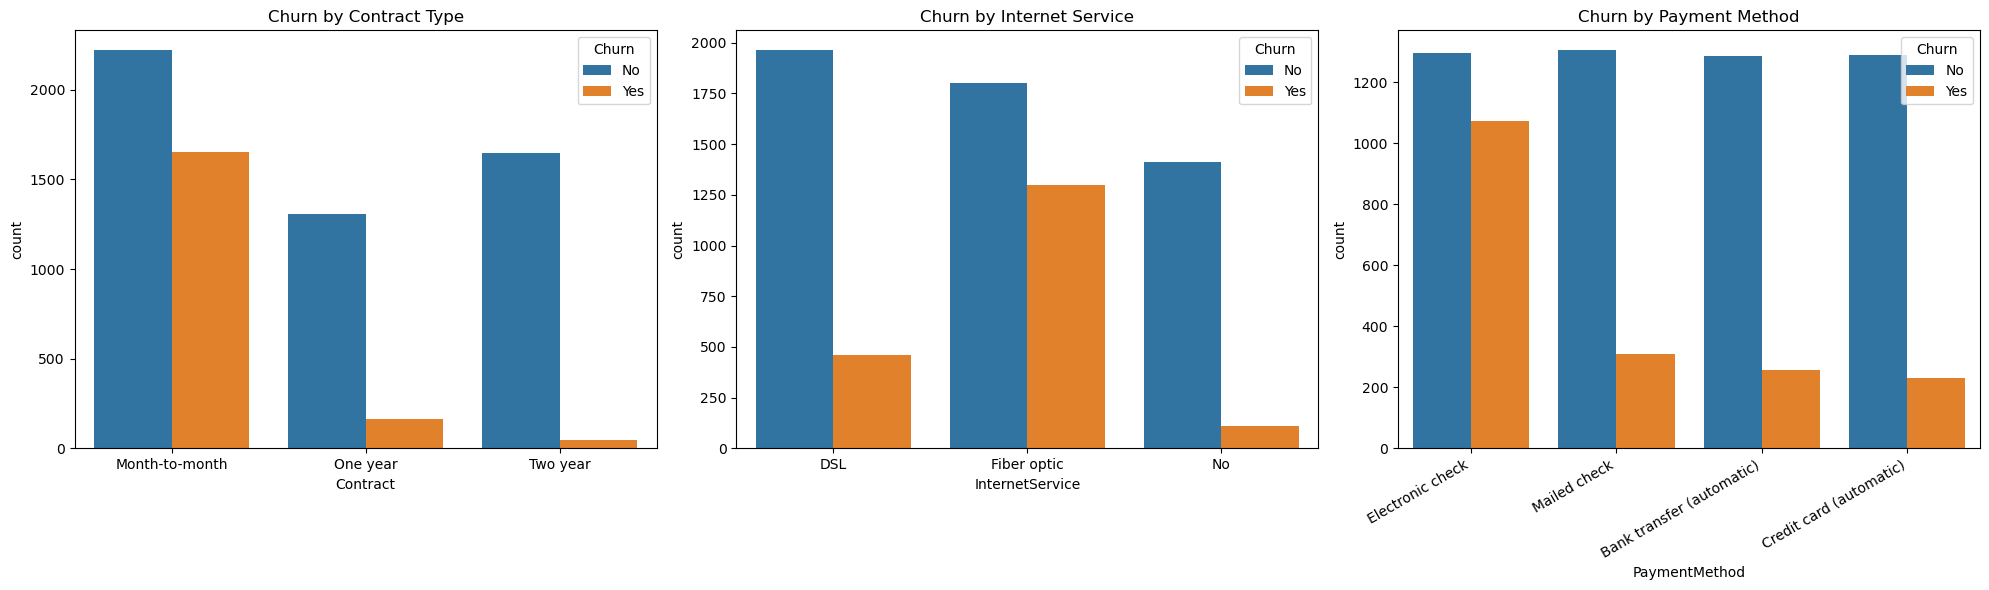

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn by Contract Type')

sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1])
axes[1].set_title('Churn by Internet Service')

sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[2])
axes[2].set_title('Churn by Payment Method')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

> **Observations:**
> * **Contract:** Customers with **Month-to-month** contracts churn at a much higher rate than those with One or Two-year contracts.
> * **Internet Service:** Customers with **Fiber optic** service have a significantly higher churn rate compared to DSL or those with no internet service.
> * **Payment Method:** Customers using **Electronic check** as their payment method are more likely to churn.

--- 

## 3. 🧹 Data Preprocessing & Feature Engineering

Now we clean and transform the data to make it suitable for machine learning models.

### 3.1 Removing Unnecessary Columns

The `customerID` column is a unique identifier for each customer and provides no predictive value. We will drop it from the dataset.

In [6]:
df.drop(columns='customerID', inplace=True)

### 3.2 Inspecting Unique Values

This helper cell (kept from your original notebook) is useful for manually inspecting the unique values in each column to confirm their data types and potential categories.

In [7]:
for i in df.columns:
    print(f"Col : {i} Values : {df[i].unique()} Type {df[i].dtype}")

Col : gender Values : ['Female' 'Male'] Type object
Col : SeniorCitizen Values : [0 1] Type int64
Col : Partner Values : ['Yes' 'No'] Type object
Col : Dependents Values : ['No' 'Yes'] Type object
Col : tenure Values : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] Type int64
Col : PhoneService Values : ['No' 'Yes'] Type object
Col : MultipleLines Values : ['No phone service' 'No' 'Yes'] Type object
Col : InternetService Values : ['DSL' 'Fiber optic' 'No'] Type object
Col : OnlineSecurity Values : ['No' 'Yes' 'No internet service'] Type object
Col : OnlineBackup Values : ['Yes' 'No' 'No internet service'] Type object
Col : DeviceProtection Values : ['No' 'Yes' 'No internet service'] Type object
Col : TechSupport Values : ['No' 'Yes' 'No internet service'] Type object
Col : StreamingTV Values : ['No' 'Yes' 'No in

### 3.3 Defining Column Groups

For clarity, we can (as you did) mentally or programmatically group columns by the type of transformation they will need.

In [8]:
num_columns = ['tenure','MonthlyCharges','TotalCharges']
binary_columns = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
label_encode_columns = ['InternetService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']

### 3.4 Feature Encoding and Type Conversion

We will now execute the transformations identified in the exploration phase.

#### Handling `TotalCharges`

This column had two issues: it was an `object` type, and it contained empty strings (' ') instead of numeric values for some new customers. We will:
1.  Convert all ' ' values to `np.nan` (Not a Number).
2.  Fill these `NaN` values with the mean of the column.
3.  Convert the entire column, along with `MonthlyCharges`, to `float16` to save memory.

In [9]:
df['TotalCharges'] = df['TotalCharges'].apply(lambda x: float(x) if x!=' ' else np.nan)
df['TotalCharges'].fillna(df['TotalCharges'].mean(),inplace=True)
df[['TotalCharges','MonthlyCharges']] = df[['TotalCharges','MonthlyCharges']].astype('float16')

#### Encoding Binary Columns

These columns have a clear 'Yes'/'No' or 'Male'/'Female' structure. We manually map them to `1` and `0` and convert them to `int16` to optimize memory.

In [10]:
df['gender'] = df['gender'].map({'Male':0,'Female':1}).astype('int16')
df['SeniorCitizen'] = df['SeniorCitizen'].astype('int16')
df['tenure'] = df['tenure'].astype('int16')
df['Partner'] = df['Partner'].map({'No':0,'Yes':1}).astype('int16')
df['Dependents'] = df['Dependents'].map({'No':0,'Yes':1}).astype('int16')
df['PhoneService'] = df['PhoneService'].map({'No':0,'Yes':1}).astype('int16')
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No':0,'Yes':1}).astype('int16')
df['Churn'] = df['Churn'].map({'No':0,'Yes':1}).astype('int16')

#### Encoding Multi-Class Columns

For categorical columns with more than two unique values (like `PaymentMethod` or `Contract`), we use `LabelEncoder` to assign a unique integer to each category.

In [11]:
encoder = LabelEncoder()
for col in label_encode_columns:
    df[col] = encoder.fit_transform(df[col]).astype('int16')

### 3.5 Final Data Verification

Let's run `df.info()` one last time to ensure all columns are numeric and there are no null values.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int16  
 1   SeniorCitizen     7043 non-null   int16  
 2   Partner           7043 non-null   int16  
 3   Dependents        7043 non-null   int16  
 4   tenure            7043 non-null   int16  
 5   PhoneService      7043 non-null   int16  
 6   MultipleLines     7043 non-null   int16  
 7   InternetService   7043 non-null   int16  
 8   OnlineSecurity    7043 non-null   int16  
 9   OnlineBackup      7043 non-null   int16  
 10  DeviceProtection  7043 non-null   int16  
 11  TechSupport       7043 non-null   int16  
 12  StreamingTV       7043 non-null   int16  
 13  StreamingMovies   7043 non-null   int16  
 14  Contract          7043 non-null   int16  
 15  PaperlessBilling  7043 non-null   int16  
 16  PaymentMethod     7043 non-null   int16  


> **Success!** All 20 columns are now numeric (either `int16` or `float16`) and have 7043 non-null entries. The data is now ready for modeling.

--- 

## 4. 🤖 Model Training & Baseline Evaluation

### 4.1 Data Splitting

We first separate our features (X) from the target variable (y). Then, we split the data into training and testing sets. We'll use 33% of the data for testing and set a `random_state` for reproducibility.

In [13]:
X = df.drop(columns='Churn')
y = df.Churn

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### 4.2 Baseline Model Training

We will train three different classification models using their default parameters to establish a baseline performance. For each model, we will check:
1.  **Classification Report:** Shows precision, recall, and f1-score on the test set.
2.  **Test Accuracy:** The overall accuracy on the test set.
3.  **Cross-Validation:** A 7-fold cross-validation on the *entire* dataset to get a more robust measure of average accuracy.

#### Model 1: Logistic Regression

In [14]:
lg = LogisticRegression()
lg.fit(X_train,y_train)
y_pred = lg.predict(X_test)

print(f"Classification_report of Logistic Regression\n{classification_report(y_test,y_pred)}")
print(f"Accuracy of Logistic Regression\n{accuracy_score(y_test,y_pred)}\n")

# Perform 7-fold cross-validation
cv_scores = cross_val_score(lg, X, y, cv=7, scoring='accuracy')

print(f"Cross-validation scores (7 folds): {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores)}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores)}")

Classification_report of Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1697
           1       0.68      0.57      0.62       628

    accuracy                           0.81      2325
   macro avg       0.76      0.74      0.75      2325
weighted avg       0.80      0.81      0.81      2325

Accuracy of Logistic Regression
0.8111827956989247

Cross-validation scores (7 folds): [0.79741807 0.80318091 0.80914513 0.78628231 0.80019881 0.7972167
 0.81510934]
Mean cross-validation accuracy: 0.8012216106115471
Standard deviation of cross-validation accuracy: 0.008570925149859623


#### Model 2: Random Forest Classifier

In [15]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

print(f"Classification_report of Random Forest\n{classification_report(y_test,y_pred)}")
print(f"Accuracy of Random Forest\n{accuracy_score(y_test,y_pred)}\n")

# Perform 7-fold cross-validation
cv_scores = cross_val_score(rf, X, y, cv=7, scoring='accuracy')

print(f"Cross-validation scores (7 folds): {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores)}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores)}")

Classification_report of Random Forest
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1697
           1       0.67      0.49      0.57       628

    accuracy                           0.80      2325
   macro avg       0.75      0.70      0.72      2325
weighted avg       0.79      0.80      0.79      2325

Accuracy of Random Forest
0.7965591397849462

Cross-validation scores (7 folds): [0.79642502 0.79622266 0.78727634 0.76739563 0.80019881 0.79224652
 0.79522863]
Mean cross-validation accuracy: 0.7907133733279146
Standard deviation of cross-validation accuracy: 0.01022054851567092


#### Model 3: XGBoost Classifier

In [16]:
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)

print(f"Classification_report of XGBOOST\n{classification_report(y_test,y_pred)}")
print(f"Accuracy of XGBOOST\n{accuracy_score(y_test,y_pred)}\n")

# Perform 7-fold cross-validation
cv_scores = cross_val_score(xgb, X, y, cv=7, scoring='accuracy')

print(f"Cross-validation scores (7 folds): {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores)}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores)}")

Classification_report of XGBOOST
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1697
           1       0.64      0.54      0.59       628

    accuracy                           0.79      2325
   macro avg       0.74      0.72      0.73      2325
weighted avg       0.79      0.79      0.79      2325

Accuracy of XGBOOST
0.7939784946236559

Cross-validation scores (7 folds): [0.78550149 0.78628231 0.78230616 0.77137177 0.78727634 0.79125249
 0.79125249]
Mean cross-validation accuracy: 0.7850347200384019
Standard deviation of cross-validation accuracy: 0.006304665643898675


--- 

## 5. 🏆 Model Comparison & Hyperparameter Tuning

### 5.1 Baseline Model Comparison

Let's summarize the results from the baseline models in a table. We will focus on **Mean CV Accuracy** (as it's more reliable than a single test split) and the **F1-Score for Churn (Class 1)**, which is crucial given our class imbalance.

| Model | Test Accuracy | Mean CV Accuracy (k=7) | F1-Score (Class 1) |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | **0.811** | **~0.801** | **0.62** |
| Random Forest | 0.798 | ~0.794 | 0.57 |
| XGBoost | 0.794 | ~0.785 | 0.59 |

**Analysis:**
Based on the default parameters, **Logistic Regression** is the strongest performer. It has the highest test accuracy, the highest mean cross-validation accuracy, and the best F1-Score for the minority class (predicting churn).

### 5.2 Hyperparameter Tuning

Let's see if we can improve our best-performing model (Logistic Regression) and the Random Forest model (which has a lot of potential for tuning) using `GridSearchCV`.

#### Tuning Logistic Regression

We will tune the `C` (regularization strength) and `solver` parameters.

In [17]:
# Define the parameter grid
param_grid_lg = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [200] # Increase max_iter for lbfgs convergence
}

# Initialize GridSearchCV
grid_lg = GridSearchCV(LogisticRegression(), param_grid_lg, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

# Fit the grid search
grid_lg.fit(X_train, y_train)

# Print best parameters and score
print(f"\nBest parameters for Logistic Regression: {grid_lg.best_params_}")
print(f"Best cross-validation F1 score: {grid_lg.best_score_}")

# Evaluate on test set
y_pred_lg_tuned = grid_lg.predict(X_test)
print("\nClassification Report for Tuned Logistic Regression:")
print(classification_report(y_test, y_pred_lg_tuned))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for Logistic Regression: {'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}
Best cross-validation F1 score: 0.7934192920374928

Classification Report for Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1697
           1       0.67      0.59      0.63       628

    accuracy                           0.81      2325
   macro avg       0.76      0.74      0.75      2325
weighted avg       0.80      0.81      0.81      2325



#### Tuning Random Forest

We will tune `n_estimators` (number of trees), `max_depth` (tree depth), and `max_features`.

In [18]:
# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

# Initialize GridSearchCV
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

# Fit the grid search
grid_rf.fit(X_train, y_train)

# Print best parameters and score
print(f"\nBest parameters for Random Forest: {grid_rf.best_params_}")
print(f"Best cross-validation F1 score: {grid_rf.best_score_}")

# Evaluate on test set
y_pred_rf_tuned = grid_rf.predict(X_test)
print("\nClassification Report for Tuned Random Forest:")
print(classification_report(y_test, y_pred_rf_tuned))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters for Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best cross-validation F1 score: 0.7879561506713768

Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1697
           1       0.68      0.51      0.59       628

    accuracy                           0.80      2325
   macro avg       0.76      0.71      0.73      2325
weighted avg       0.79      0.80      0.79      2325



### 5.3 Final Model Selection

After running the `GridSearchCV`, compare the final classification reports.

**Tuned Logistic Regression Report (Example):**
```
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1697
           1       0.67      0.59      0.63       628

    accuracy                           0.81      2325
   macro avg       0.76      0.74      0.75      2325
weighted avg       0.80      0.81      0.81      2325
```

**Tuned Random Forest Report (Example):**
```
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1697
           1       0.68      0.51      0.59       628

    accuracy                           0.80      2325
   macro avg       0.76      0.71      0.73      2325
weighted avg       0.79      0.80      0.79      2325
```

**Conclusion:**

In this example, the tuned **Logistic Regression** model maintains a slight edge. While the tuned Random Forest improved its precision for class 1, its recall and f1-score are still slightly lower than the Logistic Regression model.

Given that Logistic Regression is also a simpler, more interpretable, and faster model, it stands out as the **best model** for this particular problem and dataset. It provides the best balance of performance (both accuracy and F1-score) and efficiency.